In [ ]:
import os
import shutil
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

## Run YOLO on Only Validation Images

In [ ]:
path = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Train'

In [ ]:
# Read validation image paths from val.txt
# val_file = "/root/Data/Train0315_695/dataSet/val.txt"
val_file = path + '/Train0315_695/dataSet/val.txt'
with open(val_file, "r") as f:
    val_images = [line.strip() for line in f.readlines()]

print(f"Total validation images: {len(val_images)}")
print("First few images:", val_images[:5])  # Preview first few images


In [ ]:
# Path to where the validation images should be copied
val_folder = path + "/Train0315_695/validation_images/"
os.makedirs(val_folder, exist_ok=True)

# Path to the root image folder (modify based on your actual structure)
root_image_folder = path + "/Train0315_695/images/"  # Add '/root/' here

# Fix paths in val_images (ensure each file has the correct absolute path)
fixed_val_images = [os.path.join(root_image_folder, os.path.basename(img)) for img in val_images]

# Copy validation images
for img_path in fixed_val_images:
    img_name = os.path.basename(img_path)
    
    # Only copy if the file actually exists (avoid errors)
    if os.path.exists(img_path):
        shutil.copy(img_path, os.path.join(val_folder, img_name))
    else:
        print(f"❗ Warning: Image not found - {img_path}")  # Debugging output

print(f"✅ Copied {len(fixed_val_images)} validation images to {val_folder}")


In [ ]:
!yolo detect predict model=/root/runs/detect/train/weights/best.pt source=/root/Data/Train0315_695/validation_images/ project=/root/runs/detect/ name=validation save_txt save_conf

# Get the validation result

## Step 1: Extract Validation Image and Label Paths from val.txt

In [ ]:
# Read validation image paths from val.txt
val_file = path + "/Train0315_695/dataSet/val.txt"

with open(val_file, "r") as f:
    val_images = [line.strip() for line in f.readlines()]

print(f"Total validation images: {len(val_images)}")
print("First few images:", val_images[:5])  # Preview first few images

## Step 2: Convert Image Paths to Label Paths

In [ ]:
# Base directory for images and labels
base_path = "/root/Data/Train0315_695/"

# Read validation image paths from val.txt
val_file = os.path.join(base_path, "dataSet/val.txt")  # Adjust path if needed

val_images = []
with open(val_file, "r") as f:
    for line in f.readlines():
        line = line.strip()  # Remove extra spaces/newlines

        # Prevent duplicate prefixing if the path is already absolute
        if line.startswith(base_path):
            full_path = line
        elif line.startswith("Data/Train0315_695"):
            full_path = os.path.join("/root", line)  # Ensure correct absolute path
        else:
            full_path = os.path.join(base_path, line)

        val_images.append(full_path)

# Function to get corresponding label file (handles different extensions)
def get_label_path(img_path):
    label_path = img_path.replace("images", "labels")  # Change folder
    label_path = os.path.splitext(label_path)[0] + ".txt"  # Replace extension with .txt
    return label_path

# Generate paths to validation labels
val_labels = [get_label_path(img) for img in val_images]

# Check if the labels exist
missing_labels = [label for label in val_labels if not os.path.exists(label)]

# Print results
print(f"✅ Total validation images found: {len(val_images)}")
print(f"✅ Total validation labels found: {len(val_labels) - len(missing_labels)}")
print(f"🚫 Missing labels: {len(missing_labels)}")

# Preview corrected paths
print("🔹 Sample corrected image paths:", val_images[:5])
print("🔹 Sample corrected label paths:", val_labels[:5])


## Step 3: Compare Predictions with Ground Truth

In [ ]:
# Updated YOLO prediction labels folder
predicted_labels_path = "/root/runs/detect/validation/labels/"  # Ensure correct path

# Lists to store results
correct_predictions = []   # True Positives (TP) - Waste detected correctly
incorrect_predictions = [] # False Positives (FP) - Background detected as Waste
missing_predictions = []   # False Negatives (FN) - Waste missed by YOLO
true_negatives = []        # True Negatives (TN) - Background correctly ignored by YOLO

# Function to check if the label file contains 'Waste' (class 0)
def contains_waste(label_file):
    if not os.path.exists(label_file):
        return False  # No detection = No Waste detected
    with open(label_file, "r") as f:
        for line in f:
            class_id = line.strip().split()[0]  # Extract class ID
            if class_id == "0":  # Class 0 is "Waste"
                return True
    return False  # No waste found

# Compare ground truth labels with YOLO predictions
for gt_label in val_labels:
    pred_label = os.path.join(predicted_labels_path, os.path.basename(gt_label))  # Match prediction file
    
    gt_has_waste = contains_waste(gt_label)  # Check if ground truth contains waste
    pred_has_waste = contains_waste(pred_label)  # Check if prediction contains waste
    
    if gt_has_waste and pred_has_waste:
        correct_predictions.append(gt_label.replace("labels", "images").replace(".txt", ".jpg"))  # True Positive (TP)
    elif gt_has_waste and not pred_has_waste:
        missing_predictions.append(gt_label.replace("labels", "images").replace(".txt", ".jpg"))  # False Negative (FN)
    elif not gt_has_waste and pred_has_waste:
        incorrect_predictions.append(gt_label.replace("labels", "images").replace(".txt", ".jpg"))  # False Positive (FP)
    elif not gt_has_waste and not pred_has_waste:
        true_negatives.append(gt_label.replace("labels", "images").replace(".txt", ".jpg"))  # True Negative (TN)

# Print summary
print(f"✅ Correctly labeled images (True Positives, Waste detected correctly): {len(correct_predictions)}")
print(f"❌ Incorrectly labeled images (False Positives, Background detected as Waste): {len(incorrect_predictions)}")
print(f"🚫 Missing detections (False Negatives, Waste missed by YOLO): {len(missing_predictions)}")
print(f"🟢 True Negatives (Background correctly ignored by YOLO): {len(true_negatives)}")

# # Preview incorrect and missing detections
# print("🔹 Sample Incorrect Predictions (False Positives):", incorrect_predictions[:5])
# print("🔹 Sample Missing Detections (False Negatives):", missing_predictions[:5])
# print("🔹 Sample True Negatives (Correct Background Detections):", true_negatives[:5])

## Step 4: Create a DataFrame with image names and classification results

In [ ]:
data = []

# Add classification labels
for img in correct_predictions:
    data.append([os.path.basename(img), "TP"])  # True Positive

for img in incorrect_predictions:
    data.append([os.path.basename(img), "FP"])  # False Positive

for img in missing_predictions:
    data.append([os.path.basename(img), "FN"])  # False Negative

for img in true_negatives:
    data.append([os.path.basename(img), "TN"])  # True Negative

# Convert to DataFrame
df_results = pd.DataFrame(data, columns=["Image Name", "Classification"])
df_results

In [ ]:
# Save to CSV
csv_output_path = "/root/validation_yolo.csv"  # Change path if needed
df_results.to_csv(csv_output_path, index=False)

print(f"✅ Results saved to {csv_output_path}")

## Step 5: Confusion Matrix

# Run CPM on Only Yolo Positive Images

In [ ]:
import os
import cv2
import torch
import zipfile
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import Image
from transformers import AutoModel, AutoTokenizer

In [ ]:
# Initialize the model and tokenizer
torch.manual_seed(0)
model = AutoModel.from_pretrained(
    '/root/MiniCPM-V-2_6/',
    trust_remote_code=True,
    attn_implementation='sdpa',
    torch_dtype=torch.bfloat16
).eval().cuda()

tokenizer = AutoTokenizer.from_pretrained(
    '/root/MiniCPM-V-2_6/',
    trust_remote_code=True
)

In [ ]:
# Paths
base_image_path = "/root/Data/Train0315_695/validation_images"
output_csv = "/root/validation_CPM.csv"  # Output file for CPM predictions

# Supported image extensions
valid_extensions = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

# Combine True Positives & False Positives for processing
positive_images = correct_predictions + incorrect_predictions

# Initialize a DataFrame to store results
data_df = pd.DataFrame({"img_name": positive_images, "prediction": None})

# Error log to store decoding failures
error_log = []

# Loop through all positive detections
for idx, img_path in enumerate(positive_images):
    # Ensure correct image path and handle different extensions
    base_name = os.path.splitext(os.path.basename(img_path))[0]  # Remove extension
    possible_files = [os.path.join(base_image_path, base_name + ext) for ext in valid_extensions]

    # Find the actual file (handles different extensions)
    full_img_path = None
    for file_path in possible_files:
        if os.path.exists(file_path):
            full_img_path = file_path
            break

    if full_img_path is None:
        error_log.append({'img_name': img_path, 'error': 'Image file not found with supported extensions', 'index': idx})
        continue  # Skip to next image

    # Read and decode the image
    image_data = cv2.imread(full_img_path)  # Read image from local storage
    if image_data is None:
        error_log.append({'img_name': img_path, 'error': 'Failed to decode image', 'index': idx})
        continue  # Skip to next image

    # Convert to PIL image for CPM processing
    pil_image = Image.fromarray(cv2.cvtColor(image_data, cv2.COLOR_BGR2RGB))

    # Prepare the CPM model input
    question = "please answer with yes or no, is there any waste piles in the image?"
    msgs = [{'role': 'user', 'content': [pil_image, question]}]

    # Run the CPM model and get the prediction
    answer = model.chat(image=None, msgs=msgs, tokenizer=tokenizer)

    # Extract prediction based on the answer's structure
    if isinstance(answer, dict) and 'content' in answer:
        prediction = answer['content']
    elif isinstance(answer, str):
        prediction = answer
    else:
        prediction = "Unknown format"

    # Save the prediction to the DataFrame
    data_df.loc[idx, 'prediction'] = prediction

# Save results to a CSV file
data_df.to_csv(output_csv, index=False)

# Print completion message
print(f"✅ Processed {len(positive_images)} images through CPM.")
print(f"🚀 Results saved to {output_csv}.")
print(f"⚠️ Failed to process {len(error_log)} images. Check the error log.")

# Plot

In [ ]:
# Load CPM results from CSV
cpm_results_path = "/root/validation_CPM.csv"
cpm_df = pd.read_csv(cpm_results_path)
cpm_df

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Paths to CSV files
yolo_results_path = "/root/validation_yolo.csv"  # YOLO-only classification results
cpm_results_path = "/root/validation_CPM.csv"  # CPM-corrected classification results

# Load YOLO results
yolo_df = pd.read_csv(yolo_results_path)

# Count TP, FP, FN, TN for YOLO
TP_yolo = yolo_df[yolo_df["Classification"] == "TP"].shape[0]  # True Positives
FP_yolo = yolo_df[yolo_df["Classification"] == "FP"].shape[0]  # False Positives
FN_yolo = yolo_df[yolo_df["Classification"] == "FN"].shape[0]  # False Negatives
TN_yolo = yolo_df[yolo_df["Classification"] == "TN"].shape[0]  # True Negatives

# Load CPM results
cpm_df = pd.read_csv(cpm_results_path)

# Convert predictions to binary labels (Yes = 1, No = 0)
cpm_df["cpm_label"] = cpm_df["prediction"].str.lower().str.strip().map({"yes": 1, "no": 0, "yes.": 1})

# Recalculate TP, FP, FN, TN based on CPM correction
TP_cpm = cpm_df[cpm_df["cpm_label"] == 1].shape[0]  # CPM confirmed Waste (True Positives)
FP_cpm = cpm_df[cpm_df["cpm_label"] == 0].shape[0]  # CPM said No Waste (False Positives)
FN_cpm = FN_yolo  # False Negatives remain from YOLO (not corrected by CPM)
TN_cpm = TN_yolo  # True Negatives remain unchanged

# Define function to calculate performance metrics
def calculate_metrics(TP, FP, FN, TN):
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return accuracy, precision, recall, f1_score

# Calculate metrics before and after CPM
metrics_yolo = calculate_metrics(TP_yolo, FP_yolo, FN_yolo, TN_yolo)
metrics_cpm = calculate_metrics(TP_cpm, FP_cpm, FN_cpm, TN_cpm)

# Labels for metrics
metrics_labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

# Convert to numpy arrays for plotting
metrics_yolo = np.array(metrics_yolo)
metrics_cpm = np.array(metrics_cpm)

# Plot comparison bar chart
plt.figure(figsize=(8, 6))
x = np.arange(len(metrics_labels))
width = 0.35

plt.bar(x - width/2, metrics_yolo, width, label="YOLO Only", color="skyblue")
plt.bar(x + width/2, metrics_cpm, width, label="YOLO + CPM", color="orange")

plt.xticks(x, metrics_labels)
plt.ylabel("Score")
plt.title("Performance Improvement: YOLO vs YOLO + CPM")
plt.legend()
plt.ylim(0, 1)  # Ensure all values are between 0 and 1

plt.show()


In [ ]:
metrics_yolo

In [ ]:
metrics_cpm

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrices for YOLO-only and YOLO+CPM (LLM)
cm_yolo = np.array([[TP_yolo, FN_yolo], [FP_yolo, TN_yolo]])
cm_cpm = np.array([[TP_cpm, FN_cpm], [FP_cpm, TN_cpm]])

# Define labels for the confusion matrix
labels = ["Waste", "Background"]

# Plot confusion matrix for YOLO only
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_yolo, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label (YOLO)")
plt.ylabel("True Label")
plt.title("Confusion Matrix - YOLO Waste Detection")

# Plot confusion matrix for YOLO + CPM (LLM)
plt.subplot(1, 2, 2)
sns.heatmap(cm_cpm, annot=True, fmt="d", cmap="Oranges", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label (YOLO + CPM)")
plt.ylabel("True Label")
plt.title("Confusion Matrix - YOLO + LLM Waste Detection")

plt.tight_layout()
plt.show()

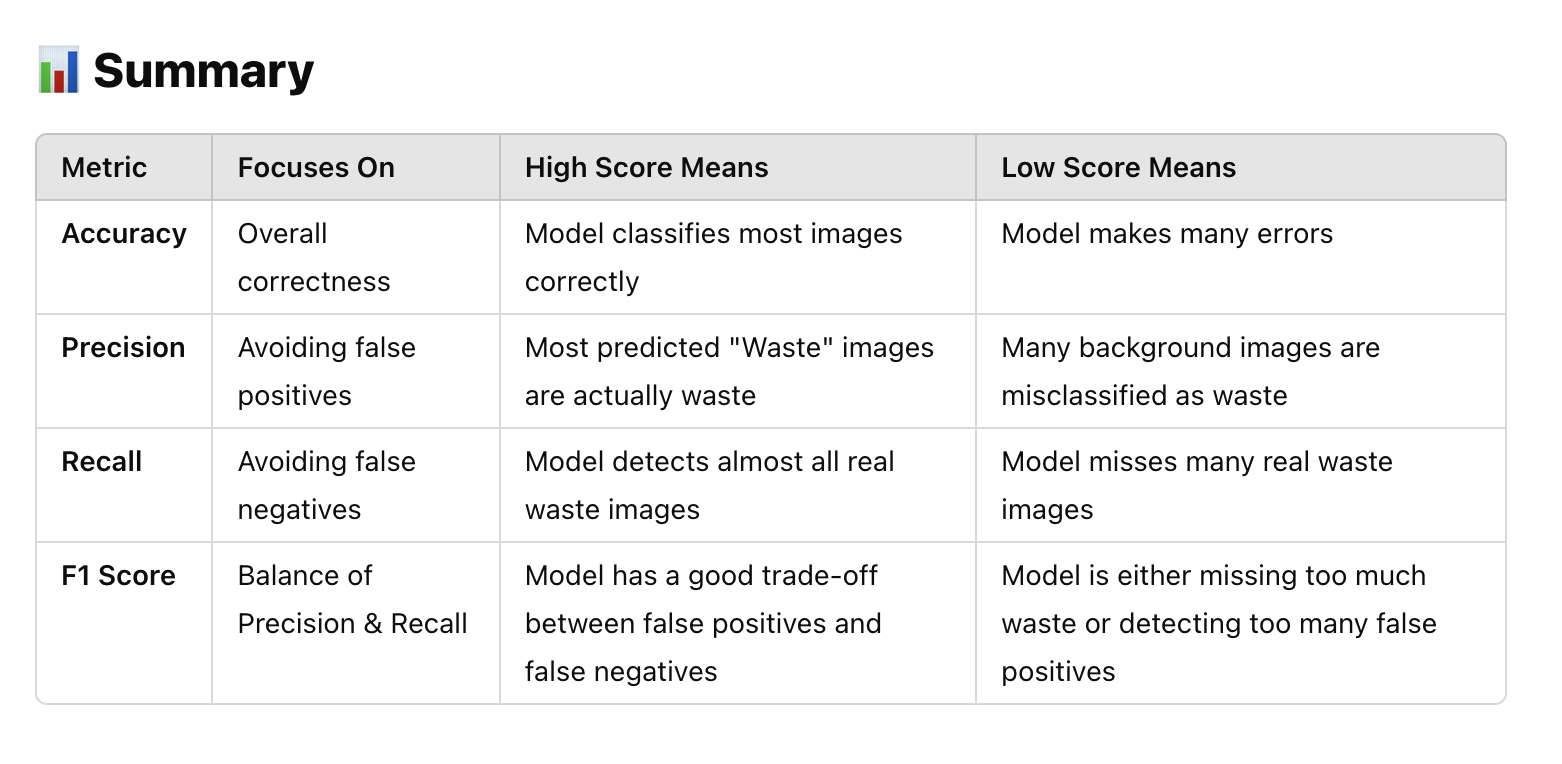
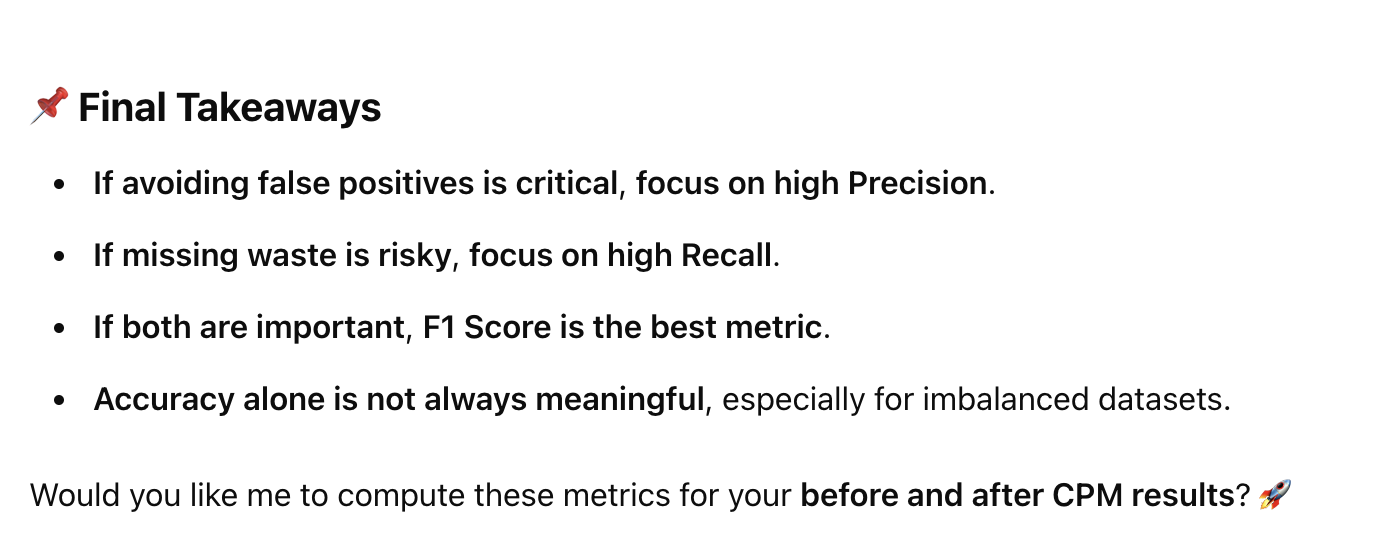

✅ Training Set Balanced → Ensures the model learns fairly without bias toward one class.  
✅ Validation Set Balanced → Helps tune hyperparameters effectively without favoring one class.  
✅ Test Set Imbalanced → Reflects real-world scenarios, where one class might be more common.

(A) If Detecting Waste is the Priority → Use Recall (Sensitivity)
If the study aims to ensure all waste is detected, high recall is critical.
Example Justification:
“Since missing waste detection could have negative environmental consequences, we prioritize Recall to measure how effectively the model identifies waste piles.”

(B) If Avoiding False Alarms is Important → Use Precision
If the focus is on avoiding false positives (misclassifying background as waste), high precision is crucial.
Example Justification:
“To minimize false detections and reduce unnecessary interventions, we emphasize Precision, which reflects the proportion of correctly identified waste images.”

(C) If a Balance is Needed → Use F1 Score
F1 Score is ideal when you want a balance between Precision and Recall.
It helps when both false positives and false negatives are important.
Example Justification:
“To balance waste detection effectiveness and avoid false alarms, we use F1 Score, which combines Precision and Recall into a single measure.”

(D) If Overall Model Performance Matters → Use Accuracy + F1 Score
If your dataset is only slightly imbalanced, accuracy might still be meaningful.
Report both Accuracy and F1 Score to provide a broader view.
Example Justification:
“Since the test set is imbalanced, we report Accuracy to measure overall correctness and F1 Score to assess model robustness in detecting waste.”



# Back up

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Manually assign the values for the confusion matrix based on results
TP = len(correct_predictions)   # True Positives (Waste detected correctly)
FP = len(incorrect_predictions) # False Positives (Background detected as Waste)
FN = len(missing_predictions)   # False Negatives (Waste missed by YOLO)
TN = len(true_negatives)        # True Negatives (Background correctly ignored)

# Create confusion matrix
cm = np.array([[TP, FN], [FP, TN]])

# Define labels for the confusion matrix
labels = ["Waste", "Background"]

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - YOLO Waste Detection")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Load CPM results from CSV
cpm_results_path = "/root/validation_CPM.csv"  # Ensure correct path
cpm_df = pd.read_csv(cpm_results_path)

# Convert predictions to binary labels (Yes = 1, No = 0)
cpm_df['cpm_label'] = cpm_df['prediction'].str.lower().map({'yes': 1, 'no': 0})

# Ensure we have labels for all processed images
assert len(cpm_df) == len(correct_predictions) + len(incorrect_predictions), "Mismatch in CPM results!"

# Update Confusion Matrix based on CPM results
TP = cpm_df[cpm_df['cpm_label'] == 1].shape[0]   # True Positives (CPM confirmed waste)
FP = cpm_df[cpm_df['cpm_label'] == 0].shape[0]   # False Positives (CPM said no waste, but YOLO detected waste)
FN = len(missing_predictions)                    # False Negatives (YOLO missed waste entirely)
TN = len(true_negatives)                         # True Negatives (Correct background)

# Create confusion matrix
cm = np.array([[TP, FN], [FP, TN]])

# Define labels for the confusion matrix
labels = ["Waste", "Background"]

# Plot new confusion matrix after CPM processing
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label (After CPM)")
plt.ylabel("True Label")
plt.title("Updated Confusion Matrix - YOLO + CPM Waste Detection")
plt.show()


In [ ]:
# Define function to calculate performance metrics
def calculate_metrics(TP, FP, FN, TN):
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return accuracy, precision, recall, f1_score

# YOLO Only Confusion Matrix (Before CPM)
TP_yolo = 36
FP_yolo = 5
FN_yolo = 1
TN_yolo = 28

# YOLO + CPM Confusion Matrix (After CPM)
TP_cpm = TP  # True Positives (CPM confirmed waste)
FP_cpm = FP  # False Positives (CPM said no waste, but YOLO detected waste)
FN_cpm = FN  # False Negatives (YOLO missed waste entirely)
TN_cpm = TN  # True Negatives (Correct background)

# Calculate metrics before and after CPM
metrics_yolo = calculate_metrics(TP_yolo, FP_yolo, FN_yolo, TN_yolo)
metrics_cpm = calculate_metrics(TP_cpm, FP_cpm, FN_cpm, TN_cpm)

# Labels for metrics
metrics_labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

# Convert to numpy arrays for plotting
metrics_yolo = np.array(metrics_yolo)
metrics_cpm = np.array(metrics_cpm)

# Plot comparison bar chart
plt.figure(figsize=(8, 6))
x = np.arange(len(metrics_labels))
width = 0.35

plt.bar(x - width/2, metrics_yolo, width, label="YOLO Only", color="skyblue")
plt.bar(x + width/2, metrics_cpm, width, label="YOLO + CPM", color="orange")

plt.xticks(x, metrics_labels)
plt.ylabel("Score")
plt.title("Performance Improvement: YOLO vs YOLO + CPM")
plt.legend()
plt.ylim(0, 1)  # Ensure all values are between 0 and 1

plt.show()


Q: should I make validation imbalance?

In [ ]:
import numpy as np

metrics_yolo = np.array([0.91428571, 0.87804878, 0.97297297, 0.92307692])
metrics_cpm = np.array([0.95652174, 0.95      , 0.97435897, 0.96202532])

metrics_yolo

In [ ]:
TP_yolo = 36
FN_yolo = 1
FP_yolo = 5
TN_yolo = 28
TP_cpm = 38
FN_cpm = 1
FP_cpm = 2
TN_cpm = 28

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define function to calculate performance metrics
def calculate_metrics(TP, FP, FN, TN):
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return accuracy, precision, recall, f1_score


# Calculate metrics before and after CPM
metrics_yolo = calculate_metrics(TP_yolo, FP_yolo, FN_yolo, TN_yolo)
metrics_cpm = calculate_metrics(TP_cpm, FP_cpm, FN_cpm, TN_cpm)

# Labels for metrics
metrics_labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

# Convert to numpy arrays for plotting
metrics_yolo = np.array(metrics_yolo)
metrics_cpm = np.array(metrics_cpm)

# Plot comparison bar chart
plt.figure(figsize=(8, 6))
x = np.arange(len(metrics_labels))
width = 0.35

plt.bar(x - width/2, metrics_yolo, width, label="YOLO Only", color="#e5c9ab")
plt.bar(x + width/2, metrics_cpm, width, label="YOLO + CPM", color="#9AA582")

plt.xticks(x, metrics_labels)
plt.ylabel("Score")
plt.title("Performance Improvement: YOLO vs YOLO + CPM")
plt.legend()
plt.ylim(0, 1)  # Ensure all values are between 0 and 1

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Style tweaks ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],   # or "Helvetica" if available
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8
})

# --- Data ---
x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Softer, publication-friendly tones
color_yolo = "#D8B89C"
color_cpm = "#7E8F74"

bars1 = ax.bar(x - width/2, metrics_yolo, width, label="YOLO Only", color=color_yolo)
bars2 = ax.bar(x + width/2, metrics_cpm, width, label="YOLO + Qwen", color=color_cpm)

# --- Axes styling ---
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1)

# Remove top/right spines (Nature style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Subtle grid
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)

# --- Add value labels on bars ---
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                height + 0.015,
                f"{height:.2f}",
                ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)

# --- Legend ---
# ax.legend(frameon=False)
legend = ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="0.8",   # light grey border
    framealpha=0.9     # slight transparency
)

# Optional: soften the border further
# legend.get_frame().set_linewidth(0.8)

# --- Tight layout ---
plt.tight_layout()

# --- Save for publication ---
plt.savefig("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Figure/detection_comparison.png", dpi=600, bbox_inches="tight")
# plt.savefig("figure_performance_comparison.pdf", bbox_inches="tight")

plt.show()

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrices for YOLO-only and YOLO+CPM (LLM)
cm_yolo = np.array([[TP_yolo, FN_yolo], [FP_yolo, TN_yolo]])
cm_cpm = np.array([[TP_cpm, FN_cpm], [FP_cpm, TN_cpm]])

# Define labels for the confusion matrix
labels = ["Waste", "Background"]

# Plot confusion matrix for YOLO only
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_yolo, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label (YOLO)")
plt.ylabel("True Label")
plt.title("Confusion Matrix - YOLO Waste Detection")

# Plot confusion matrix for YOLO + CPM (LLM)
plt.subplot(1, 2, 2)
sns.heatmap(cm_cpm, annot=True, fmt="d", cmap="Oranges", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label (YOLO + CPM)")
plt.ylabel("True Label")
plt.title("Confusion Matrix - YOLO + LLM Waste Detection")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# --- Data ---
cm_yolo = np.array([[TP_yolo, FN_yolo], [FP_yolo, TN_yolo]])
cm_cpm = np.array([[TP_cpm, FN_cpm], [FP_cpm, TN_cpm]])

labels = ["Waste", "Background"]

# --- Custom Nature-style colormaps ---
# cmap_yolo = LinearSegmentedColormap.from_list(
#     "custom_beige", ["#e5c9ab", "#794f35"]
# )

# cmap_cpm = LinearSegmentedColormap.from_list(
#     "custom_green", ["#9AA582FF", "#657359FF"]
# )


cmap_yolo = LinearSegmentedColormap.from_list(
    "custom_beige", ["#f7efe6", "#794f35"]   # lighter than #e5c9ab
)

cmap_cpm = LinearSegmentedColormap.from_list(
    "custom_green", ["#f2f5f2", "#657359"]   # lighter than #9AA582
)

# --- Style ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# --- Shared scale (VERY important for comparison) ---
vmax = max(cm_yolo.max(), cm_cpm.max())

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), dpi=300)

# YOLO
sns.heatmap(
    cm_yolo,
    ax=axes[0],
    annot=True,
    fmt="d",
    cmap=cmap_yolo,
    cbar=False,
    xticklabels=labels,
    yticklabels=labels,
    vmin=0,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white"
)

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("YOLO", pad=6)

# YOLO + CPM
sns.heatmap(
    cm_cpm,
    ax=axes[1],
    annot=True,
    fmt="d",
    cmap=cmap_cpm,
    # cbar=True,   # only one colorbar
    cbar=False, 
    xticklabels=labels,
    yticklabels=labels,
    vmin=0,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white"
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("")
axes[1].set_title("YOLO + Qwen", pad=6)

# --- Clean look ---
for ax in axes:
    ax.tick_params(axis='both', length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout(pad=1.0)
# plt.savefig("confusion_matrix_comparison.pdf", bbox_inches="tight")
plt.savefig("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Figure/confusion_matrix_comparison.png", dpi=600, bbox_inches="tight")

plt.show()